In [1]:
import os
import sys

sys.path.append(os.path.dirname(os.getcwd())) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from datetime import datetime, timedelta

from src.constants import hustle_stats
from src.steps.model.model import CompositeEffort
from src.steps.ingest.process_data import ProcessData

pd.set_option('display.max_columns', None)

In [2]:
DATA_DIR = '../data/'
DATA_DIR_RAW = os.path.join(DATA_DIR, 'raw_data')
lgl_path = os.path.join(DATA_DIR_RAW, 'df_logs.csv')


df_logs = pd.read_csv(lgl_path)
hustle_files = [f for f in os.listdir(DATA_DIR_RAW) if f.startswith('df_hustle')]
hustle_paths = [os.path.join(DATA_DIR_RAW, f) for f in hustle_files]
df_hustle_list = [pd.read_csv(f) for f in hustle_paths]
df_hustle = pd.concat(df_hustle_list)
df_hustle = df_hustle.drop_duplicates()
ff_files = [f for f in os.listdir(DATA_DIR_RAW) if f.startswith('df_four_factors')]
ff_paths = [os.path.join(DATA_DIR_RAW, f) for f in ff_files]
df_ff_list = [pd.read_csv(f) for f in ff_paths]
df_ff = pd.concat(df_ff_list)
df_ff.drop_duplicates()



neutral_game_ids = [22400147, 22401230, 22401229, 22400621, 22400633]
neutral_home_teams = ['WAS','OKC','ATL','IND','SAS']
neutral_dict = dict(zip(neutral_game_ids,neutral_home_teams))




In [3]:
display(df_logs.head(2))
display(df_hustle.head(2))
display(df_ff.head(2))

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,22022,1610612738,BOS,Boston Celtics,22200001,2022-10-18,BOS vs. PHI,W,240,46,82,0.561,12,35,0.343,22,28,0.786,6,30,36,24,8,3,11,24,126,9,1
1,22022,1610612755,PHI,Philadelphia 76ers,22200001,2022-10-18,PHI @ BOS,L,240,40,80,0.500,13,34,0.382,24,28,0.857,4,27,31,16,8,3,14,25,117,-9,1


,GAME_ID,TEAM_ID,TEAM_NAME,TEAM_ABBREVIATION,TEAM_CITY,MINUTES,PTS,CONTESTED_SHOTS,CONTESTED_SHOTS_2PT,CONTESTED_SHOTS_3PT,DEFLECTIONS,CHARGES_DRAWN,SCREEN_ASSISTS,SCREEN_AST_PTS,OFF_LOOSE_BALLS_RECOVERED,DEF_LOOSE_BALLS_RECOVERED,LOOSE_BALLS_RECOVERED,OFF_BOXOUTS,DEF_BOXOUTS,BOX_OUT_PLAYER_TEAM_REBS,BOX_OUT_PLAYER_REBS,BOX_OUTS
0,22401108,1610612765,Pistons,DET,Detroit,240.0:00,103,51,32,19,10,1,6,16,1,3,4,2,8,10,7,10
1,22401108,1610612760,Thunder,OKC,Oklahoma City,239.0:00,119,51,32,19,18,0,11,25,1,3,4,1,3,4,3,4


,GAME_ID,TEAM_ID,TEAM_NAME,TEAM_ABBREVIATION,TEAM_CITY,MIN,EFG_PCT,FTA_RATE,TM_TOV_PCT,OREB_PCT,OPP_EFG_PCT,OPP_FTA_RATE,OPP_TOV_PCT,OPP_OREB_PCT
0,22201002,1610612759,Spurs,SAS,San Antonio,240:00,0.612,0.181,0.178,0.333,0.561,0.222,0.132,0.174
1,22201002,1610612743,Nuggets,DEN,Denver,240:00,0.561,0.222,0.132,0.174,0.612,0.181,0.178,0.333


In [4]:
proc_data = ProcessData(df_logs = df_logs, df_hustle=df_hustle, df_four_factors=df_ff, neutral_dict=neutral_dict)

2025-09-06 21:27:14,163 [INFO] df_logs shape: (7380, 29)
2025-09-06 21:27:14,164 [INFO] df_hustle shape: (7380, 22)
2025-09-06 21:27:14,164 [INFO] df_four_factors shape: (7380, 14)


In [5]:
output_dir = os.path.join(DATA_DIR, 'processed_data')
df_proc = proc_data.process_data(output_dir=output_dir)

2025-09-06 21:27:14,254 [INFO] Process df_logs...
2025-09-06 21:27:14,286 [INFO] Converting long to wide format...
2025-09-06 21:27:14,301 [INFO] Added neutral and home indicator columns
2025-09-06 21:27:14,302 [INFO] Processing df_logs complete
2025-09-06 21:27:14,302 [INFO] df_proc_logs shape: (3690, 38)
2025-09-06 21:27:14,303 [INFO] Process df_hustle data...
2025-09-06 21:27:14,312 [INFO] Processing df_hustle complete
2025-09-06 21:27:14,313 [INFO] df_proc_hustle shape: (3690, 33)
2025-09-06 21:27:14,313 [INFO] Process df_four_factors...
2025-09-06 21:27:14,320 [INFO] Processing df_four_factors complete
2025-09-06 21:27:14,320 [INFO] df_proc_four_factors shape: (3690, 11)
2025-09-06 21:27:14,321 [INFO] Joining df_proc_hustle and df_proc_four_factors to df_logs...
2025-09-06 21:27:14,324 [INFO] Join complete
2025-09-06 21:27:14,324 [INFO] df_proc shape: (3690, 76)
2025-09-06 21:27:14,367 [INFO] Saved processed data to ../data/processed_data/df_processed.csv


In [6]:
df_proc.head(2)

,SEASON_ID,GAME_ID,GAME_DATE,AWAY_TEAM_ID,HOME_TEAM_ID,AWAY_TEAM_ABBREVIATION,HOME_TEAM_ABBREVIATION,AWAY_TEAM_NAME,HOME_TEAM_NAME,AWAY_FGM,HOME_FGM,AWAY_FGA,HOME_FGA,AWAY_FG3M,HOME_FG3M,AWAY_FG3A,HOME_FG3A,AWAY_FTM,HOME_FTM,AWAY_FTA,HOME_FTA,AWAY_OREB,HOME_OREB,AWAY_DREB,HOME_DREB,AWAY_AST,HOME_AST,AWAY_STL,HOME_STL,AWAY_BLK,HOME_BLK,AWAY_TOV,HOME_TOV,AWAY_PF,HOME_PF,AWAY_PTS,HOME_PTS,NEUTRAL_IND,AWAY_SCREEN_ASSISTS,HOME_SCREEN_ASSISTS,AWAY_CONTESTED_SHOTS,HOME_CONTESTED_SHOTS,AWAY_BOX_OUT_PLAYER_TEAM_REBS,HOME_BOX_OUT_PLAYER_TEAM_REBS,AWAY_DEF_BOXOUTS,HOME_DEF_BOXOUTS,AWAY_BOX_OUT_PLAYER_REBS,HOME_BOX_OUT_PLAYER_REBS,AWAY_LOOSE_BALLS_RECOVERED,HOME_LOOSE_BALLS_RECOVERED,AWAY_SCREEN_AST_PTS,HOME_SCREEN_AST_PTS,AWAY_DEF_LOOSE_BALLS_RECOVERED,HOME_DEF_LOOSE_BALLS_RECOVERED,AWAY_OFF_BOXOUTS,HOME_OFF_BOXOUTS,AWAY_CONTESTED_SHOTS_3PT,HOME_CONTESTED_SHOTS_3PT,AWAY_BOX_OUTS,HOME_BOX_OUTS,AWAY_CONTESTED_SHOTS_2PT,HOME_CONTESTED_SHOTS_2PT,AWAY_OFF_LOOSE_BALLS_RECOVERED,HOME_OFF_LOOSE_BALLS_RECOVERED,AWAY_CHARGES_DRAWN,HOME_CHARGES_DRAWN,AWAY_DEFLECTIONS,HOME_DEFLECTIONS,AWAY_EFG_PCT,HOME_EFG_PCT,AWAY_TM_TOV_PCT,HOME_TM_TOV_PCT,AWAY_FTA_RATE,HOME_FTA_RATE,AWAY_OREB_PCT,HOME_OREB_PCT
0,22022,22200001,2022-10-18,1610612755,1610612738,PHI,BOS,Philadelphia 76ers,Boston Celtics,40,46,80,82,13,12,34,35,24,22,28,28,4,6,27,30,16,24,8,8,3,3,14,11,25,24,117,126,0,9,10,27,34,6,2,6,2,4,0,1,4,19,22,1,2,0,0,12,15,6,2,15,19,0,2,0,2,16,16,0.581,0.634,0.143,0.113,0.350,0.341,0.190,0.256
1,22022,22200002,2022-10-18,1610612747,1610612744,LAL,GSW,Los Angeles Lakers,Golden State Warriors,40,45,94,99,10,16,40,45,19,17,25,23,9,11,39,37,23,31,12,11,4,4,22,18,18,23,109,123,0,3,18,71,63,13,12,11,11,7,6,7,3,8,43,2,2,2,3,36,33,13,14,35,30,5,1,1,1,18,22,0.479,0.535,0.196,0.157,0.266,0.232,0.246,0.281


In [7]:
from src.steps.transform.transform import TransformData

In [8]:
transform_data = TransformData(df_proc = df_proc)

output_dir = os.path.join(DATA_DIR, 'transformed_data')
df_trans = transform_data.engineered_features(output_dir=output_dir)


In [9]:
df_trans.head(2)

,SEASON_ID,GAME_ID,GAME_DATE,AWAY_TEAM_ID,HOME_TEAM_ID,AWAY_TEAM_ABBREVIATION,HOME_TEAM_ABBREVIATION,AWAY_TEAM_NAME,HOME_TEAM_NAME,AWAY_FGM,HOME_FGM,AWAY_FGA,HOME_FGA,AWAY_FG3M,HOME_FG3M,AWAY_FG3A,HOME_FG3A,AWAY_FTM,HOME_FTM,AWAY_FTA,HOME_FTA,AWAY_OREB,HOME_OREB,AWAY_DREB,HOME_DREB,AWAY_AST,HOME_AST,AWAY_STL,HOME_STL,AWAY_BLK,HOME_BLK,AWAY_TOV,HOME_TOV,AWAY_PF,HOME_PF,AWAY_PTS,HOME_PTS,NEUTRAL_IND,AWAY_SCREEN_ASSISTS,HOME_SCREEN_ASSISTS,AWAY_CONTESTED_SHOTS,HOME_CONTESTED_SHOTS,AWAY_BOX_OUT_PLAYER_TEAM_REBS,HOME_BOX_OUT_PLAYER_TEAM_REBS,AWAY_DEF_BOXOUTS,HOME_DEF_BOXOUTS,AWAY_BOX_OUT_PLAYER_REBS,HOME_BOX_OUT_PLAYER_REBS,AWAY_LOOSE_BALLS_RECOVERED,HOME_LOOSE_BALLS_RECOVERED,AWAY_SCREEN_AST_PTS,HOME_SCREEN_AST_PTS,AWAY_DEF_LOOSE_BALLS_RECOVERED,HOME_DEF_LOOSE_BALLS_RECOVERED,AWAY_OFF_BOXOUTS,HOME_OFF_BOXOUTS,AWAY_CONTESTED_SHOTS_3PT,HOME_CONTESTED_SHOTS_3PT,AWAY_BOX_OUTS,HOME_BOX_OUTS,AWAY_CONTESTED_SHOTS_2PT,HOME_CONTESTED_SHOTS_2PT,AWAY_OFF_LOOSE_BALLS_RECOVERED,HOME_OFF_LOOSE_BALLS_RECOVERED,AWAY_CHARGES_DRAWN,HOME_CHARGES_DRAWN,AWAY_DEFLECTIONS,HOME_DEFLECTIONS,AWAY_EFG_PCT,HOME_EFG_PCT,AWAY_TM_TOV_PCT,HOME_TM_TOV_PCT,AWAY_FTA_RATE,HOME_FTA_RATE,AWAY_OREB_PCT,HOME_OREB_PCT,EST_HOME_POSS,EST_AWAY_POSS,EST_HOME_ORtg,EST_AWAY_ORtg,EST_HOME_NRtg,EST_AWAY_NRtg,SCREEN_AST_PTS_DIFF,DEFLECTIONS_DIFF,CONTESTED_SHOTS_DIFF,DEF_BOXOUTS_DIFF,CONTESTED_SHOTS_2PT_DIFF,BOX_OUT_PLAYER_TEAM_REBS_DIFF,CHARGES_DRAWN_DIFF,LOOSE_BALLS_RECOVERED_DIFF,OFF_BOXOUTS_DIFF,BOX_OUTS_DIFF,DEF_LOOSE_BALLS_RECOVERED_DIFF,SCREEN_ASSISTS_DIFF,BOX_OUT_PLAYER_REBS_DIFF,OFF_LOOSE_BALLS_RECOVERED_DIFF,CONTESTED_SHOTS_3PT_DIFF,EFG_PCT_DIFF,FTA_RATE_DIFF,TM_TOV_PCT_DIFF,OREB_PCT_DIFF
0,22022,22200001,2022-10-18,1610612755,1610612738,PHI,BOS,Philadelphia 76ers,Boston Celtics,40,46,80,82,13,12,34,35,24,22,28,28,4,6,27,30,16,24,8,8,3,3,14,11,25,24,117,126,0,9,10,27,34,6,2,6,2,4,0,1,4,19,22,1,2,0,0,12,15,6,2,15,19,0,2,0,2,16,16,0.581,0.634,0.143,0.113,0.350,0.341,0.190,0.256,99.32,102.32,126.862666,114.347146,12.515520,-12.515520,3,0,7,-4,4,-4,2,3,0,-4,1,1,-4,2,3,0.053,-0.009,-0.030,0.066
1,22022,22200002,2022-10-18,1610612747,1610612744,LAL,GSW,Los Angeles Lakers,Golden State Warriors,40,45,94,99,10,16,40,45,19,17,25,23,9,11,39,37,23,31,12,11,4,4,22,18,18,23,109,123,0,3,18,71,63,13,12,11,11,7,6,7,3,8,43,2,2,2,3,36,33,13,14,35,30,5,1,1,1,18,22,0.479,0.535,0.196,0.157,0.266,0.232,0.246,0.281,116.12,118.00,105.924905,92.372881,13.552024,-13.552024,35,4,-8,0,-5,-1,0,-4,1,1,0,15,-1,-4,-3,0.056,-0.034,-0.039,0.035


In [13]:
df_trans.columns[df_trans.columns.str.contains('EST')]

Index(['AWAY_CONTESTED_SHOTS', 'HOME_CONTESTED_SHOTS',
       'AWAY_CONTESTED_SHOTS_3PT', 'HOME_CONTESTED_SHOTS_3PT',
       'AWAY_CONTESTED_SHOTS_2PT', 'HOME_CONTESTED_SHOTS_2PT', 'EST_HOME_POSS',
       'EST_AWAY_POSS', 'EST_HOME_ORtg', 'EST_AWAY_ORtg', 'EST_HOME_NRtg',
       'EST_AWAY_NRtg', 'CONTESTED_SHOTS_DIFF', 'CONTESTED_SHOTS_2PT_DIFF',
       'CONTESTED_SHOTS_3PT_DIFF'],
      dtype='object')

In [12]:
# Step 1 - Create Effort Variable

# Step 1a - Create offensive effort



,SEASON_ID,GAME_ID,GAME_DATE,AWAY_TEAM_ID,HOME_TEAM_ID,AWAY_TEAM_ABBREVIATION,HOME_TEAM_ABBREVIATION,AWAY_TEAM_NAME,HOME_TEAM_NAME,AWAY_FGM,HOME_FGM,AWAY_FGA,HOME_FGA,AWAY_FG3M,HOME_FG3M,AWAY_FG3A,HOME_FG3A,AWAY_FTM,HOME_FTM,AWAY_FTA,HOME_FTA,AWAY_OREB,HOME_OREB,AWAY_DREB,HOME_DREB,AWAY_AST,HOME_AST,AWAY_STL,HOME_STL,AWAY_BLK,HOME_BLK,AWAY_TOV,HOME_TOV,AWAY_PF,HOME_PF,AWAY_PTS,HOME_PTS,NEUTRAL_IND,AWAY_SCREEN_ASSISTS,HOME_SCREEN_ASSISTS,AWAY_CONTESTED_SHOTS,HOME_CONTESTED_SHOTS,AWAY_BOX_OUT_PLAYER_TEAM_REBS,HOME_BOX_OUT_PLAYER_TEAM_REBS,AWAY_DEF_BOXOUTS,HOME_DEF_BOXOUTS,AWAY_BOX_OUT_PLAYER_REBS,HOME_BOX_OUT_PLAYER_REBS,AWAY_LOOSE_BALLS_RECOVERED,HOME_LOOSE_BALLS_RECOVERED,AWAY_SCREEN_AST_PTS,HOME_SCREEN_AST_PTS,AWAY_DEF_LOOSE_BALLS_RECOVERED,HOME_DEF_LOOSE_BALLS_RECOVERED,AWAY_OFF_BOXOUTS,HOME_OFF_BOXOUTS,AWAY_CONTESTED_SHOTS_3PT,HOME_CONTESTED_SHOTS_3PT,AWAY_BOX_OUTS,HOME_BOX_OUTS,AWAY_CONTESTED_SHOTS_2PT,HOME_CONTESTED_SHOTS_2PT,AWAY_OFF_LOOSE_BALLS_RECOVERED,HOME_OFF_LOOSE_BALLS_RECOVERED,AWAY_CHARGES_DRAWN,HOME_CHARGES_DRAWN,AWAY_DEFLECTIONS,HOME_DEFLECTIONS,AWAY_EFG_PCT,HOME_EFG_PCT,AWAY_TM_TOV_PCT,HOME_TM_TOV_PCT,AWAY_FTA_RATE,HOME_FTA_RATE,AWAY_OREB_PCT,HOME_OREB_PCT,EST_HOME_POSS,EST_AWAY_POSS,EST_HOME_ORtg,EST_AWAY_ORtg,EST_HOME_NRtg,EST_AWAY_NRtg,SCREEN_AST_PTS_DIFF,DEFLECTIONS_DIFF,CONTESTED_SHOTS_DIFF,DEF_BOXOUTS_DIFF,CONTESTED_SHOTS_2PT_DIFF,BOX_OUT_PLAYER_TEAM_REBS_DIFF,CHARGES_DRAWN_DIFF,LOOSE_BALLS_RECOVERED_DIFF,OFF_BOXOUTS_DIFF,BOX_OUTS_DIFF,DEF_LOOSE_BALLS_RECOVERED_DIFF,SCREEN_ASSISTS_DIFF,BOX_OUT_PLAYER_REBS_DIFF,OFF_LOOSE_BALLS_RECOVERED_DIFF,CONTESTED_SHOTS_3PT_DIFF,EFG_PCT_DIFF,FTA_RATE_DIFF,TM_TOV_PCT_DIFF,OREB_PCT_DIFF
2606,22024,22400147,2024-11-02,1610612748,1610612764,MIA,WAS,Miami Heat,Washington Wizards,43,38,102,91,15,7,37,35,17,15,24,21,21,8,44,36,19,23,6,12,3,10,14,12,18,22,118,98,1,12,8,43,58,15,4,14,3,5,1,9,6,30,16,3,2,3,1,16,19,17,4,27,39,6,4,0,0,15,18,0.495,0.456,0.136,0.117,0.235,0.231,0.391,0.193,104.24,105.56,94.013814,111.784767,-17.770953,17.770953,-14,3,15,-11,12,-11,0,-3,-2,-13,-1,-4,-4,-2,3,-0.039,-0.004,-0.019,-0.198
3080,22024,22400621,2025-01-23,1610612759,1610612754,SAS,IND,San Antonio Spurs,Indiana Pacers,58,44,96,97,18,13,36,43,6,9,6,12,15,9,42,22,43,31,10,10,10,2,20,11,13,9,140,110,1,4,9,48,41,6,7,4,3,2,6,4,4,9,20,4,2,2,4,25,19,6,7,23,22,0,2,0,0,14,18,0.698,0.521,0.192,0.105,0.063,0.124,0.421,0.200,104.28,103.64,105.485232,135.082980,-29.597747,29.597747,11,4,-7,-1,-1,1,0,0,2,1,-2,5,4,2,-6,-0.177,0.061,-0.087,-0.221
3092,22024,22400633,2025-01-25,1610612754,1610612759,IND,SAS,Indiana Pacers,San Antonio Spurs,53,35,102,85,17,11,39,32,13,17,14,25,16,15,34,29,32,22,14,9,9,5,10,24,20,17,136,98,1,11,4,41,44,9,1,8,2,5,0,10,5,27,9,4,3,2,0,17,12,10,2,24,32,6,2,0,0,20,15,0.603,0.476,0.098,0.235,0.137,0.294,0.380,0.333,105.00,102.16,93.333333,133.124511,-39.791177,39.791177,-18,-5,3,-6,8,-8,0,-5,-2,-8,-1,-7,-5,-4,-5,-0.127,0.157,0.137,-0.047
3688,22024,22401229,2024-12-14,1610612749,1610612737,MIL,ATL,Milwaukee Bucks,Atlanta Hawks,39,35,86,82,14,10,45,24,18,22,27,34,6,7,41,37,28,23,8,3,8,6,13,13,27,20,110,102,1,5,11,44,48,11,2,11,2,1,2,5,3,14,26,2,3,0,0,11,28,11,2,33,20,3,0,0,0,14,17,0.535,0.488,0.124,0.125,0.314,0.415,0.200,0.154,102.96,104.88,99.067599,104.881770,-5.814171,5.814171,12,3,4,-9,-13,-9,0,-2,0,-9,1,6,1,-3,17,-0.047,0.101,0.001,-0.046
3689,22024,22401230,2024-12-14,1610612745,1610612760,HOU,OKC,Houston Rockets,Oklahoma City Thunder,35,36,96,80,11,11,46,30,15,28,25,32,19,4,30,39,17,19,7,12,3,4,16,12,25,24,96,111,1,4,8,35,48,4,8,2,8,4,5,3,4,9,19,1,2,3,0,14,24,5,8,21,24,2,2,0,1,11,27,0.422,0.519,0.162,0.121,0.260,0.400,0.382,0.205,102.08,104.00,108.738245,92.307692,16.430552,-16.430552,10,16,13,6,3,4,1,1,-3,3,1,4,1,0,10,0.097,0.140,-0.041,-0.177


In [6]:
len(df_ff_list), df_ff.shape, df_ff2.shape

(149, (14760, 14), (7380, 14))

In [10]:
df_ff2.head()

,GAME_ID,TEAM_ID,TEAM_NAME,TEAM_ABBREVIATION,TEAM_CITY,MIN,EFG_PCT,FTA_RATE,TM_TOV_PCT,OREB_PCT,OPP_EFG_PCT,OPP_FTA_RATE,OPP_TOV_PCT,OPP_OREB_PCT
0,22201002,1610612759,Spurs,SAS,San Antonio,240:00,0.612,0.181,0.178,0.333,0.561,0.222,0.132,0.174
1,22201002,1610612743,Nuggets,DEN,Denver,240:00,0.561,0.222,0.132,0.174,0.612,0.181,0.178,0.333
2,22200999,1610612764,Wizards,WAS,Washington,240:00,0.528,0.205,0.146,0.239,0.521,0.200,0.137,0.296
3,22200999,1610612737,Hawks,ATL,Atlanta,240:00,0.521,0.200,0.137,0.296,0.528,0.205,0.146,0.239
4,22201001,1610612750,Timberwolves,MIN,Minnesota,265:00,0.536,0.296,0.127,0.298,0.549,0.363,0.138,0.275


In [11]:
df_ff2.isna().sum()

GAME_ID              0
TEAM_ID              0
TEAM_NAME            0
TEAM_ABBREVIATION    0
TEAM_CITY            0
MIN                  0
EFG_PCT              0
FTA_RATE             0
TM_TOV_PCT           0
OREB_PCT             0
OPP_EFG_PCT          0
OPP_FTA_RATE         0
OPP_TOV_PCT          0
OPP_OREB_PCT         0
dtype: int64

In [12]:
df_ff2.describe()

,GAME_ID,TEAM_ID,EFG_PCT,FTA_RATE,TM_TOV_PCT,OREB_PCT,OPP_EFG_PCT,OPP_FTA_RATE,OPP_TOV_PCT,OPP_OREB_PCT
count,7.380000e+03,7.380000e+03,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000
mean,2.230062e+07,1.610613e+09,0.546267,0.254349,0.139693,0.283468,0.546267,0.254349,0.139693,0.283468
std,8.165596e+04,8.656028e+00,0.065848,0.086998,0.038267,0.074614,0.065848,0.086998,0.038267,0.074614
min,2.220000e+07,1.610613e+09,0.331000,0.000000,0.020000,0.022000,0.331000,0.000000,0.020000,0.022000
25%,2.220092e+07,1.610613e+09,0.500000,0.194000,0.112000,0.231750,0.500000,0.194000,0.112000,0.231750
50%,2.230062e+07,1.610613e+09,0.545000,0.244000,0.138000,0.283000,0.545000,0.244000,0.138000,0.283000
75%,2.240031e+07,1.610613e+09,0.590000,0.308000,0.165000,0.333000,0.590000,0.308000,0.165000,0.333000
max,2.240123e+07,1.610613e+09,0.804000,0.697000,0.302000,0.553000,0.804000,0.697000,0.302000,0.553000


<Axes: xlabel='TEAM_ABBREVIATION', ylabel='EFG_PCT'>

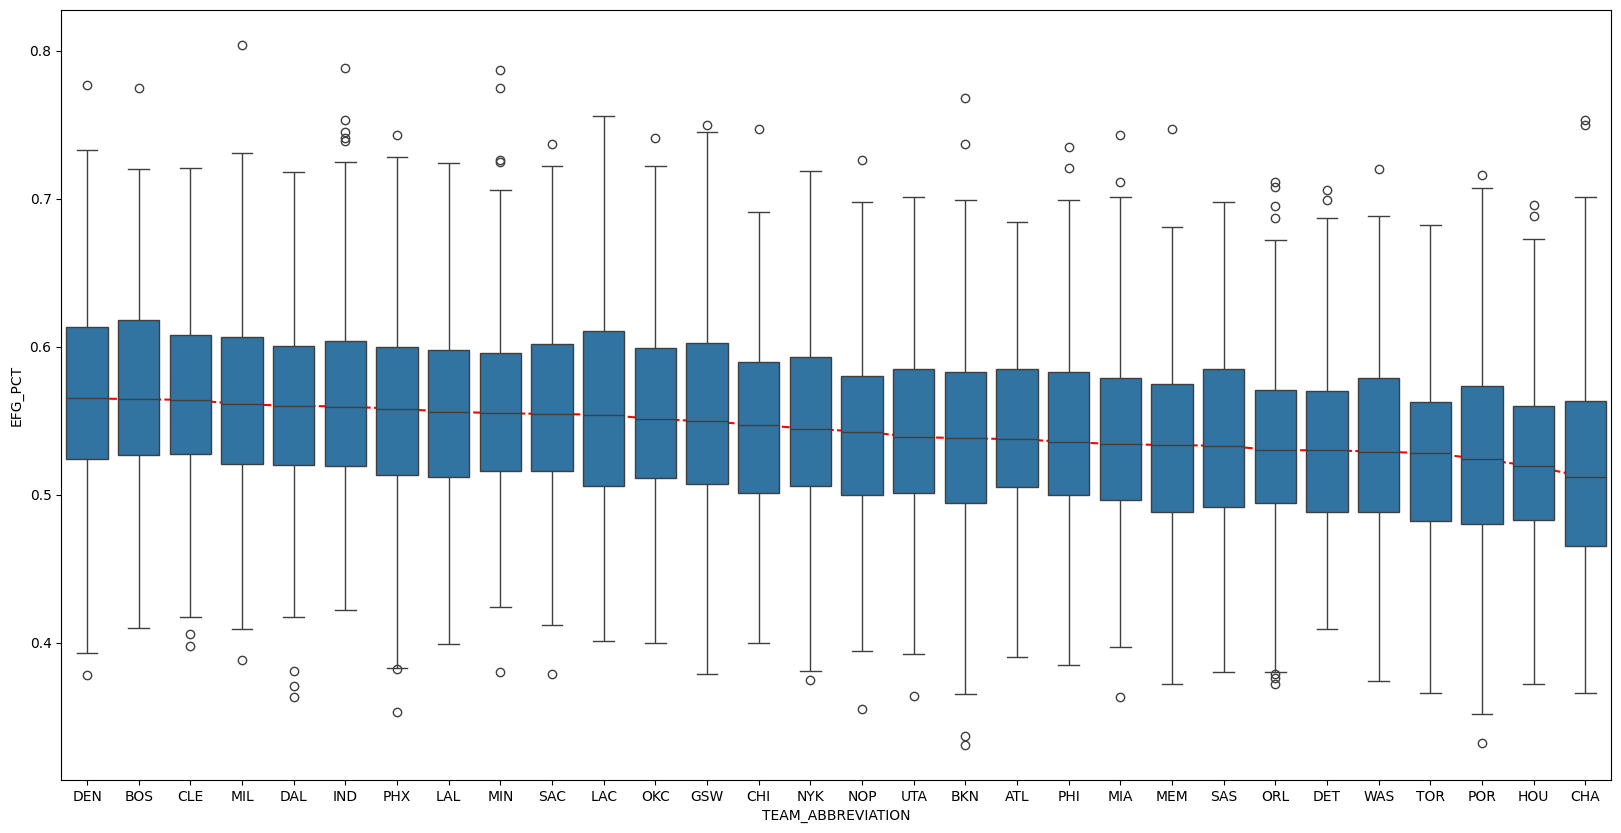

In [22]:
df_grp = df_ff2.groupby('TEAM_ABBREVIATION')['EFG_PCT'].agg('median').reset_index()

df_grp = df_grp.sort_values('EFG_PCT', ascending=False)
plt.figure(figsize=(20,10))
sns.lineplot(x='TEAM_ABBREVIATION', y='EFG_PCT', data=df_grp, color='red', linestyle='dashed')
sns.boxplot(x='TEAM_ABBREVIATION',y='EFG_PCT', data=df_ff2)

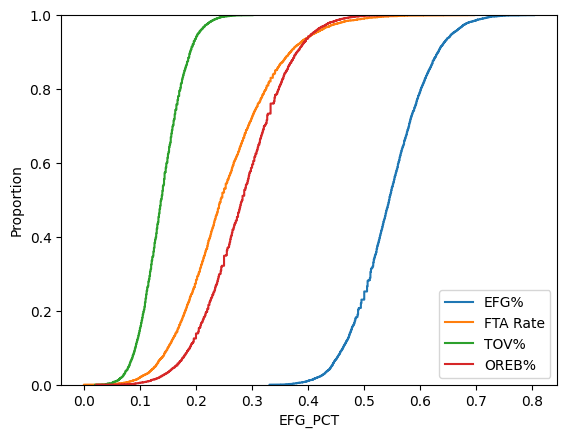

In [25]:
sns.ecdfplot(x='EFG_PCT', data=df_ff2, label='EFG%')
sns.ecdfplot(x='FTA_RATE', data=df_ff2, label='FTA Rate')
sns.ecdfplot(x='TM_TOV_PCT', data=df_ff2, label='TOV%')
sns.ecdfplot(x='OREB_PCT', data=df_ff2, label='OREB%')
plt.legend(loc='best')

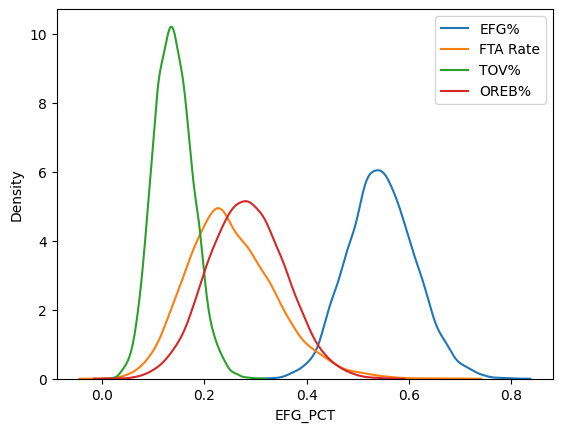

In [26]:
sns.kdeplot(x='EFG_PCT', data=df_ff2, label='EFG%')
sns.kdeplot(x='FTA_RATE', data=df_ff2, label='FTA Rate')
sns.kdeplot(x='TM_TOV_PCT', data=df_ff2, label='TOV%')
sns.kdeplot(x='OREB_PCT', data=df_ff2, label='OREB%')
plt.legend(loc='best')

In [27]:
# Read in Data
lgl_path = os.path.join(DATA_DIR,'raw_data', 'df_logs.csv')
df_logs = pd.read_csv(lgl_path)

In [28]:
def process_logs(df, neutral_dict) -> pd.DataFrame:
        
    df = df.copy()
    
    # Add home team indicator
    df['HOME_IND'] = np.where(df['MATCHUP'].str.contains('@'),'AWAY','HOME')

    # Handle handful of international games manually --> figure out more robust solution later...
    neutral_games_idx = []
    for game_id, home_team in self.neutral_dict.items():
        neutral_games_idx.append(df[(df['GAME_ID']==game_id) & (df['TEAM_ABBREVIATION']==home_team)].index.values[0])
    df.loc[neutral_games_idx, 'HOME_IND'] = 'HOME'
    
    
    # Define columns
    team_cols = ['TEAM_ID','TEAM_ABBREVIATION','TEAM_NAME','FGM','FGA','FG3M','FG3A','FTM','FTA','OREB','DREB','AST','STL','BLK','TOV','PF','PTS']
    non_team_cols = ['SEASON_ID','GAME_ID','GAME_DATE']

    # Pivot data (convert 2 rows per game to 1 row per game)
    df_pivoted = df.set_index(non_team_cols+['HOME_IND'])[team_cols].unstack('HOME_IND')

    # Flatten column names
    df_pivoted.columns = [f"{home_ind}_{col}" for col, home_ind in df_pivoted.columns]
    self.df_proc_logs = df_pivoted.reset_index()
    
    # Add neutral indicator column
    self.df_proc_logs['NEUTRAL_IND'] = 0
    self.df_proc_logs.loc[self.df_proc_logs['GAME_ID'].isin(list(self.neutral_dict.keys())), 'NEUTRAL_IND'] = 1

    return self.df_proc_logs

def process_ff(df_ff, df_logs):
    df_ff = df_ff.copy()
    df_logs = df_logs.copy()
    df_logs.rename(columns={'TEAM_ID','
    
    # Join home indicator to hustle data (already accounts for neutral games from df_proc_logs)
    df_home_ind = df_logs[['GAME_ID','HOME_TEAM_ID']].copy()
    df_home_ind['HOME_IND'] = 'HOME'
    df_ff = df_ff.merge(
        df_home_ind, 
        left_on=['GAME_ID','TEAM_ID'],
        right_on=['GAME_ID','HOME_TEAM_ID'],
        how='left'
    )
    df_ff.loc[df_ff['HOME_IND'].isna(), 'HOME_IND'] = 'AWAY'
    
    # Drop unnecessary columns
    cols_to_drop = ['TEAM_NAME','TEAM_ABBREVIATION','TEAM_CITY','MINUTES','PTS','HOME_TEAM_ID']
    df_ff.drop(cols_to_drop, axis=1, inplace=True)
    
    # Convert from long to wide
    team_cols = list(set(df_ff.columns)-set(['GAME_ID','HOME_IND']))
    df_ff_pivoted = df_ff.set_index(['GAME_ID','HOME_IND'])[team_cols].unstack('HOME_IND')
    
    df_ff_pivoted.columns = [f"{home_ind}_{col}" for col, home_ind in df_ff_pivoted.columns]
    df_proc_ff = df_ff_pivoted.reset_index()
    
    return df_proc_ff

In [29]:
df_proc_ff = process_ff(df_ff=df_ff2, df_logs=df_logs)

KeyError: "['HOME_TEAM_ID'] not in index"

In [30]:
df_logs.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,22022,1610612738,BOS,Boston Celtics,22200001,2022-10-18,BOS vs. PHI,W,240,46,82,0.561,12,35,0.343,22,28,0.786,6,30,36,24,8,3,11,24,126,9,1
1,22022,1610612755,PHI,Philadelphia 76ers,22200001,2022-10-18,PHI @ BOS,L,240,40,80,0.500,13,34,0.382,24,28,0.857,4,27,31,16,8,3,14,25,117,-9,1
2,22022,1610612744,GSW,Golden State Warriors,22200002,2022-10-18,GSW vs. LAL,W,240,45,99,0.455,16,45,0.356,17,23,0.739,11,37,48,31,11,4,18,23,123,14,1
3,22022,1610612747,LAL,Los Angeles Lakers,22200002,2022-10-18,LAL @ GSW,L,240,40,94,0.426,10,40,0.250,19,25,0.760,9,39,48,23,12,4,22,18,109,-14,1
4,22022,1610612759,SAS,San Antonio Spurs,22200011,2022-10-19,SAS vs. CHA,L,240,40,99,0.404,7,34,0.206,15,21,0.714,14,30,44,22,8,8,15,19,102,-27,1
